This ipynb file is made to add perturbations (noise) to the selected .wav files (with already Wiener filter)

In [10]:
# Standard libraries
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import shutil


from scipy.io import wavfile
from scipy.signal import wiener

# load data
DATA_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME"
WIENER_INPUT_DIR = os.path.join(DATA_PATH, "wiener_filtered_audio")
WHITE_NOISE_OUTPUT_DIR = os.path.join(DATA_PATH, "wiener_white_noise_perturbations")

os.makedirs(GAUSSIAN_OUTPUT_DIR, exist_ok=True)

In [11]:
# Collect WAV files
wiener_audio_files = []

for root, dirs, files in os.walk(WIENER_INPUT_DIR):
    for file in files:
        if file.endswith(".wav"):
            wiener_audio_files.append(os.path.join(root, file))

print(f"Number of Wiener-filtered audio files: {len(wiener_audio_files)}")

Number of Wiener-filtered audio files: 1941


In [12]:
def load_wav_file(file_path):
    sample_rate, signal = wavfile.read(file_path)
    return sample_rate, signal


def save_wav_file(file_path, sample_rate, signal):
    signal = np.clip(signal, -32768, 32767)
    signal = signal.astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)

def add_white_noise(signal, noise_std_fraction):
    """
    Add white noise to an audio signal.
    Parameters
    signal : np.ndarray
    noise_std_fraction : float

    Returns
    noisy_signal : np.ndarray
    """
    signal = signal.astype(np.float32)

    # Standard deviation of the original signal
    signal_std = np.std(signal)

    # Standard deviation of the noise
    noise_std = noise_std_fraction * signal_std

    # Generate white noise
    noise = np.random.normal(loc=0.0, scale=noise_std, size=signal.shape)

    noisy_signal = signal + noise
    return noisy_signal

def make_perturbation_output_path(input_path, input_root, output_root, perturbation_name):
    relative_path = os.path.relpath(input_path, input_root)
    output_path = os.path.join(output_root, perturbation_name, relative_path)

    output_dir = os.path.dirname(output_path)
    os.makedirs(output_dir, exist_ok=True)

    return output_path

In [13]:
perturbations = {
    "low_white_noise": 0.005,
    "medium_white_noise": 0.02,
    "high_white_noise": 0.05,
    "very_high_white_noise": 0.1
}

In [14]:
processed_rows = []

for input_path in wiener_audio_files:
    try:
        sample_rate, signal = load_wav_file(input_path)

        for perturbation_name, noise_std_fraction in perturbations.items():
            noisy_signal = add_white_noise(signal, noise_std_fraction)

            output_path = make_perturbation_output_path(
                input_path=input_path,
                input_root=WIENER_INPUT_DIR,
                output_root=WHITE_NOISE_OUTPUT_DIR,
                perturbation_name=perturbation_name
            )

            save_wav_file(output_path, sample_rate, noisy_signal)

            participant_id = os.path.basename(os.path.dirname(input_path))
            filename = os.path.basename(input_path)

            processed_rows.append({
                "participant_id": participant_id,
                "filename": filename,
                "original_wiener_file_path": input_path,
                "perturbation": perturbation_name,
                "noise_std_fraction": noise_std_fraction,
                "perturbed_file_path": output_path
            })

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

print("Finished processing White noise perturbations.")

Finished processing White noise perturbations.


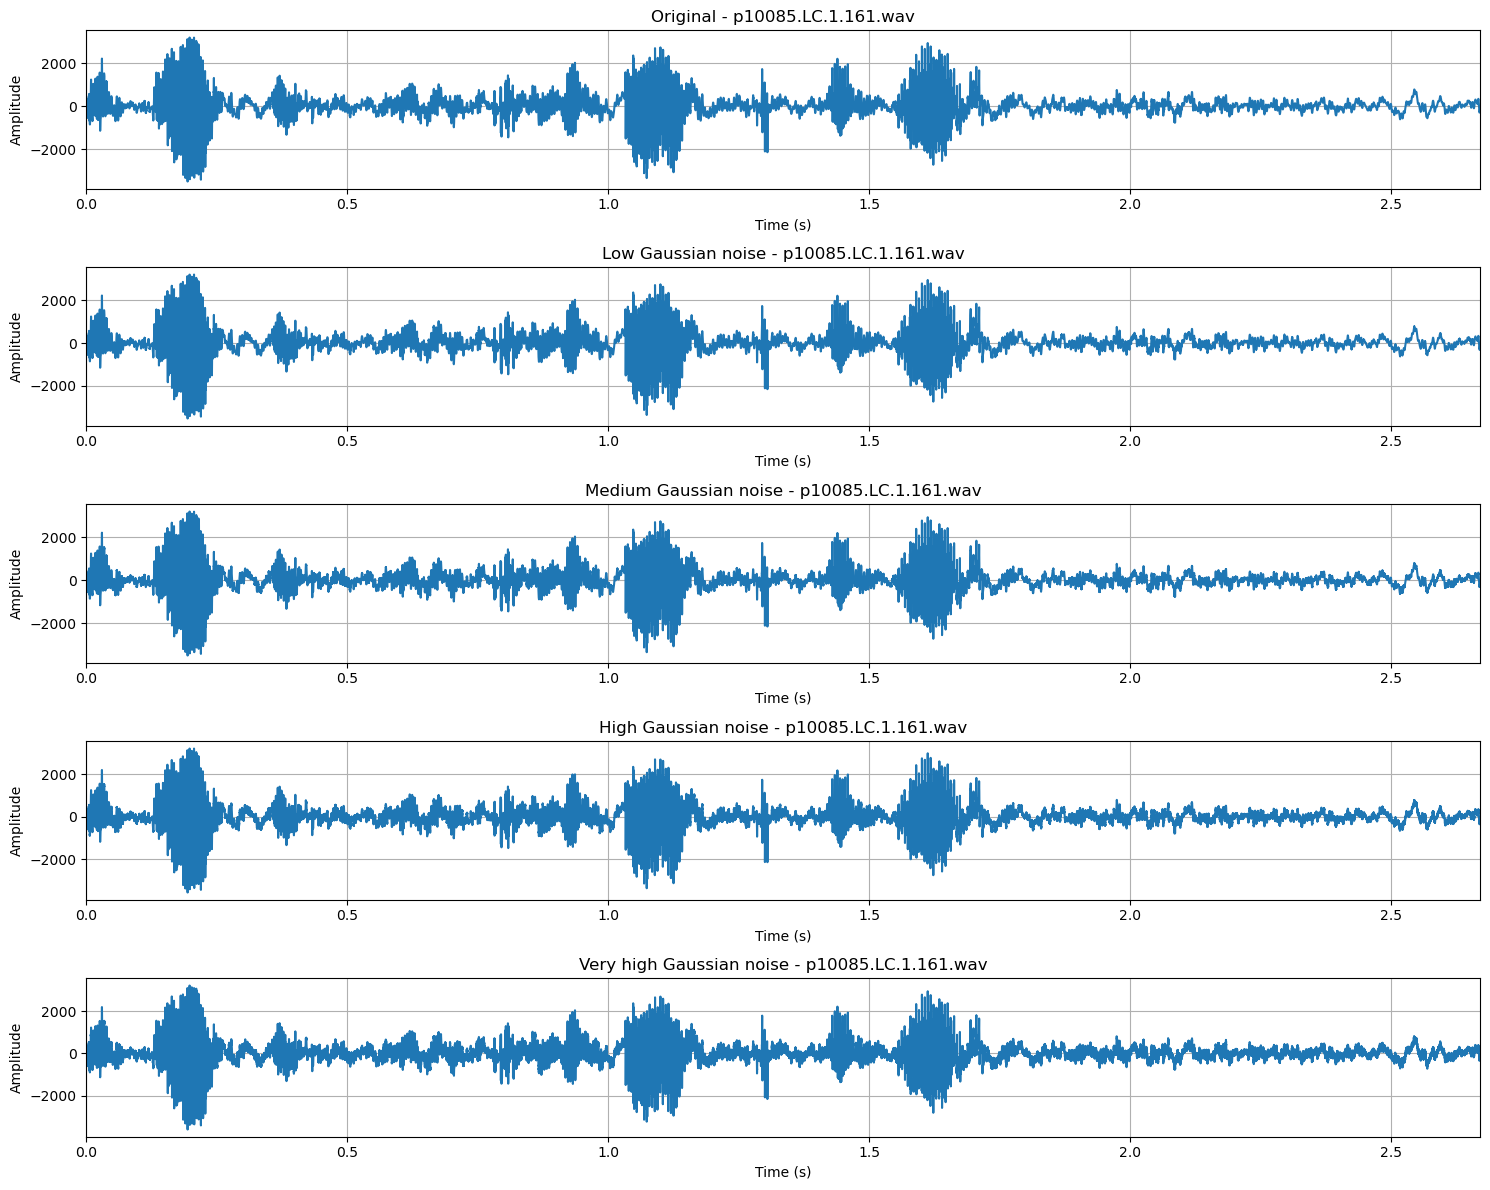

In [15]:
# which participant plot
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)

perturbed_files = {
    "Original": original_file,
    "Low Gaussian noise": os.path.join(WHITE_NOISE_OUTPUT_DIR, "low_white_noise", participant_id, filename),
    "Medium Gaussian noise": os.path.join(WHITE_NOISE_OUTPUT_DIR, "medium_white_noise", participant_id, filename),
    "High Gaussian noise": os.path.join(WHITE_NOISE_OUTPUT_DIR, "high_white_noise", participant_id, filename),
    "Very high Gaussian noise": os.path.join(WHITE_NOISE_OUTPUT_DIR, "very_high_white_noise", participant_id, filename),
}


# Plot
plt.figure(figsize=(15, 12))

for i, (label, file_path) in enumerate(perturbed_files.items(), 1):
    sample_rate, signal = load_wav_file(file_path)
    signal = signal.astype(np.float32)

    time = np.arange(len(signal)) / sample_rate

    plt.subplot(5, 1, i)
    plt.plot(time, signal)
    plt.title(f"{label} - {filename}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, min(3, time[-1]))  # first 3 seconds
    plt.grid(True)

plt.tight_layout()
plt.show()

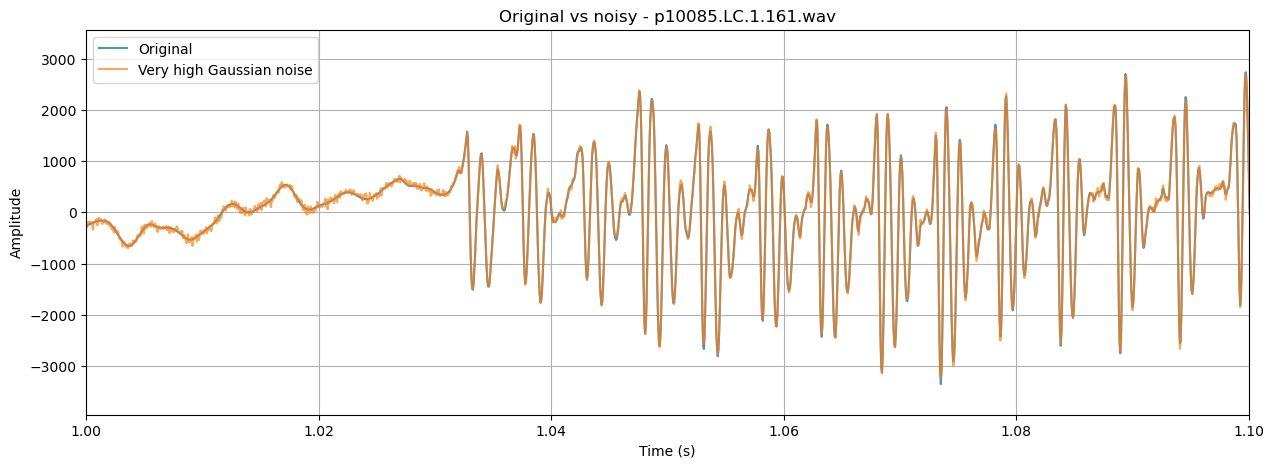

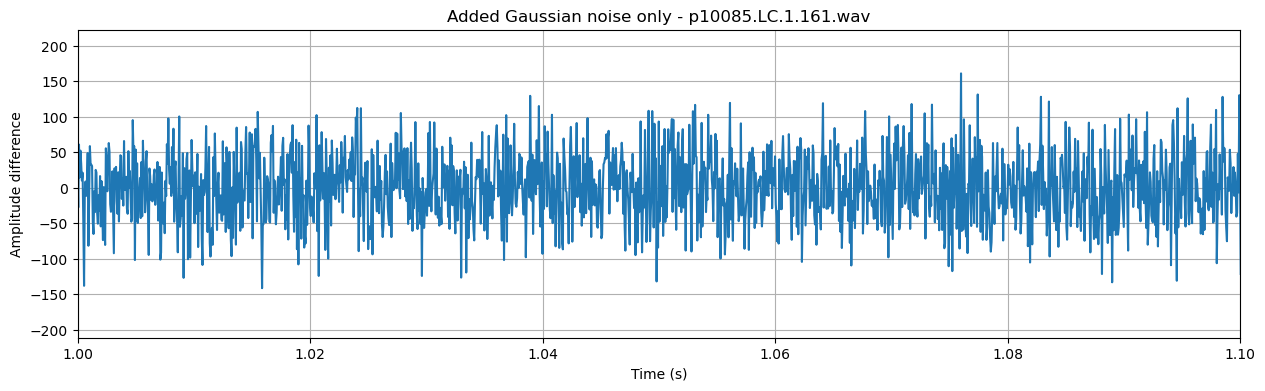

In [17]:
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)
noisy_file = os.path.join(WHITE_NOISE_OUTPUT_DIR, "very_high_white_noise", participant_id, filename)

sr_orig, signal_orig = load_wav_file(original_file)
sr_noisy, signal_noisy = load_wav_file(noisy_file)

signal_orig = signal_orig.astype(np.float32)
signal_noisy = signal_noisy.astype(np.float32)

time = np.arange(len(signal_orig)) / sr_orig

plt.figure(figsize=(15, 5))
plt.plot(time, signal_orig, label="Original", alpha=0.8)
plt.plot(time, signal_noisy, label="Very high Gaussian noise", alpha=0.7)
plt.xlim(1.0, 1.1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Original vs noisy - {filename}")
plt.legend()
plt.grid(True)
plt.show()

difference = signal_noisy - signal_orig

plt.figure(figsize=(15, 4))
plt.plot(time, difference)
plt.xlim(1.0, 1.1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude difference")
plt.title(f"Added Gaussian noise only - {filename}")
plt.grid(True)
plt.show()